# Demonstration of MLP Model Training

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lobaton/DM2026-Deep-Learning-with-Python/blob/main/Src/Gait-MLP.ipynb)

**Problem Statement:** *We are aiming to develop a personalize model that determine when a person is walking fast or slow. We have conducted two recording sessions, in which the individual switches between fast and slow walking periodically. Let's build a model that predicts which gait it is observed in the data.*

We start by downloading the data.

## Exploratory Data Analysis (EDA) on Gait Accelerometer Data

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch
import seaborn as sns

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Define the file paths
file_path_1p5_2p0 = '/content/data_1p5_2p0.csv'
file_path_1p5_3p0 = '/content/data_1p5_3p0.csv'

# Load both CSV files into pandas DataFrames
df_1p5_2p0 = pd.read_csv(file_path_1p5_2p0)
df_1p5_3p0 = pd.read_csv(file_path_1p5_3p0)

print('Datasets loaded successfully.')

Datasets loaded successfully.


### 1. Data Inspection

First, let's inspect the dataframes to understand their structure, data types, and check for any missing values. We will also verify the sampling rate and display summary statistics grouped by the 'Label' column.

In [ ]:
print("\n--- Dataset: 1.5 Hz to 2.0 Hz Cadence (df_1p5_2p0) ---")
print(df_1p5_2p0.info())
print("\nMissing values:\n", df_1p5_2p0.isnull().sum())

print("\n--- Dataset: 1.5 Hz to 3.0 Hz Cadence (df_1p5_3p0) ---")
print(df_1p5_3p0.info())
print("\nMissing values:\n", df_1p5_3p0.isnull().sum())


--- Dataset: 1.5 Hz to 2.0 Hz Cadence (df_1p5_2p0) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  20000 non-null  float64
 1   Signal     20000 non-null  float64
 2   Label      20000 non-null  object 
dtypes: float64(2), object(1)
memory usage: 468.9+ KB
None

Missing values:
 Timestamp    0
Signal       0
Label        0
dtype: int64

--- Dataset: 1.5 Hz to 3.0 Hz Cadence (df_1p5_3p0) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  20000 non-null  float64
 1   Signal     20000 non-null  float64
 2   Label      20000 non-null  object 
dtypes: float64(2), object(1)
memory usage: 468.9+ KB
None

Missing values:
 Timestamp    0
Signal       0
Label        0
dtype: int64


#### Verify Sampling Rate

The `Timestamp` column is expected to be sampled at 100 Hz (0.01s intervals). Let's verify this by checking the difference between consecutive timestamps.

In [ ]:
sampling_rate_1p5_2p0 = 1 / df_1p5_2p0['Timestamp'].diff().mode()[0]
sampling_rate_1p5_3p0 = 1 / df_1p5_3p0['Timestamp'].diff().mode()[0]

print(f"\nSampling Rate for df_1p5_2p0: {sampling_rate_1p5_2p0:.2f} Hz")
print(f"Sampling Rate for df_1p5_3p0: {sampling_rate_1p5_3p0:.2f} Hz")

# Ensure Timestamp is treated as a time series for later steps if needed
df_1p5_2p0['Timestamp'] = pd.to_numeric(df_1p5_2p0['Timestamp'])
df_1p5_3p0['Timestamp'] = pd.to_numeric(df_1p5_3p0['Timestamp'])


Sampling Rate for df_1p5_2p0: 100.00 Hz
Sampling Rate for df_1p5_3p0: 100.00 Hz


#### Summary Statistics Grouped by 'Label'

Now, let's look at the descriptive statistics for the 'Signal' column, separated by 'slow' and 'fast' labels.

In [ ]:
print("\n--- Summary Statistics for df_1p5_2p0 by Label ---")
display(df_1p5_2p0.groupby('Label')['Signal'].describe())

print("\n--- Summary Statistics for df_1p5_3p0 by Label ---")
display(df_1p5_3p0.groupby('Label')['Signal'].describe())


--- Summary Statistics for df_1p5_2p0 by Label ---


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
fast,10000.0,0.000195,0.707438,-1.194914,-0.702252,-0.004322,0.700830,1.180729
slow,10000.0,0.000080,0.710160,-1.226734,-0.702739,-0.002756,0.705491,1.199581



--- Summary Statistics for df_1p5_3p0 by Label ---


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
fast,10000.0,0.000195,0.706805,-1.195706,-0.701445,-0.003227,0.702878,1.215323
slow,10000.0,-0.000059,0.710646,-1.203898,-0.704950,-0.002512,0.706104,1.218212


### 2. Time-Series Visualization

Let's visualize 20-second snapshots of the `Signal` for both sessions. We will shade the background based on the 'Label' ('slow' vs 'fast') to clearly illustrate the gait transitions.

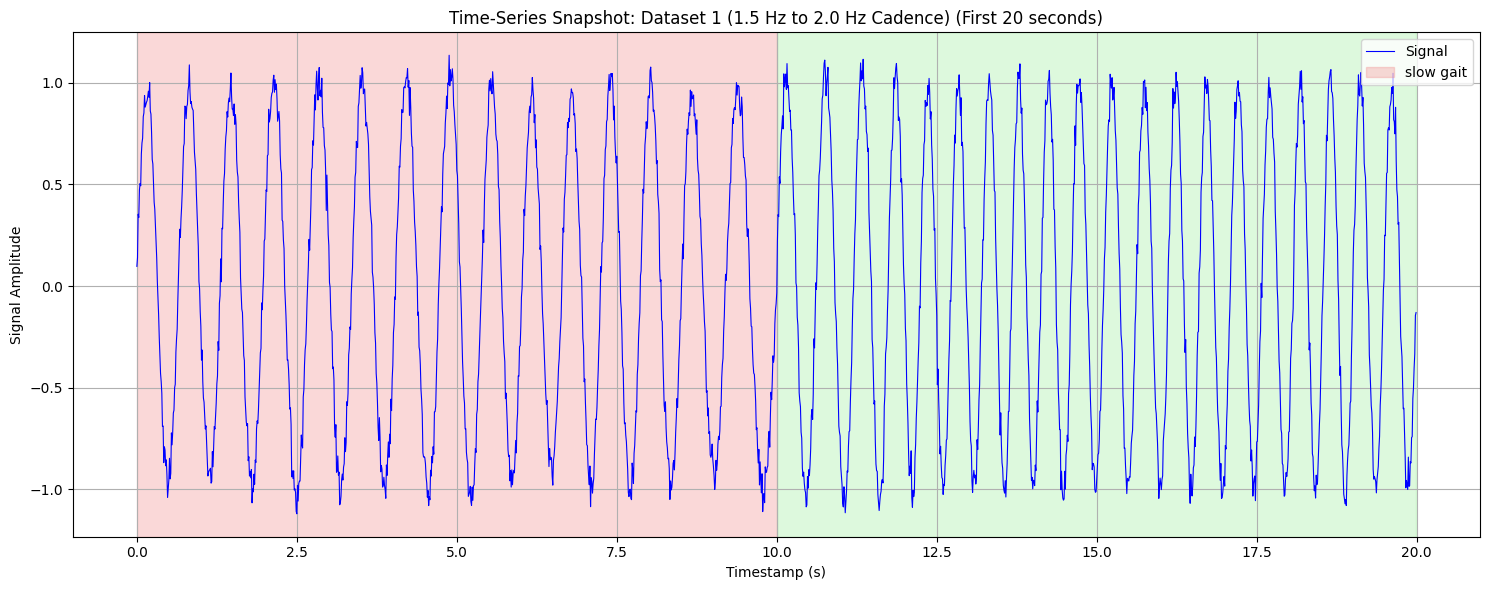

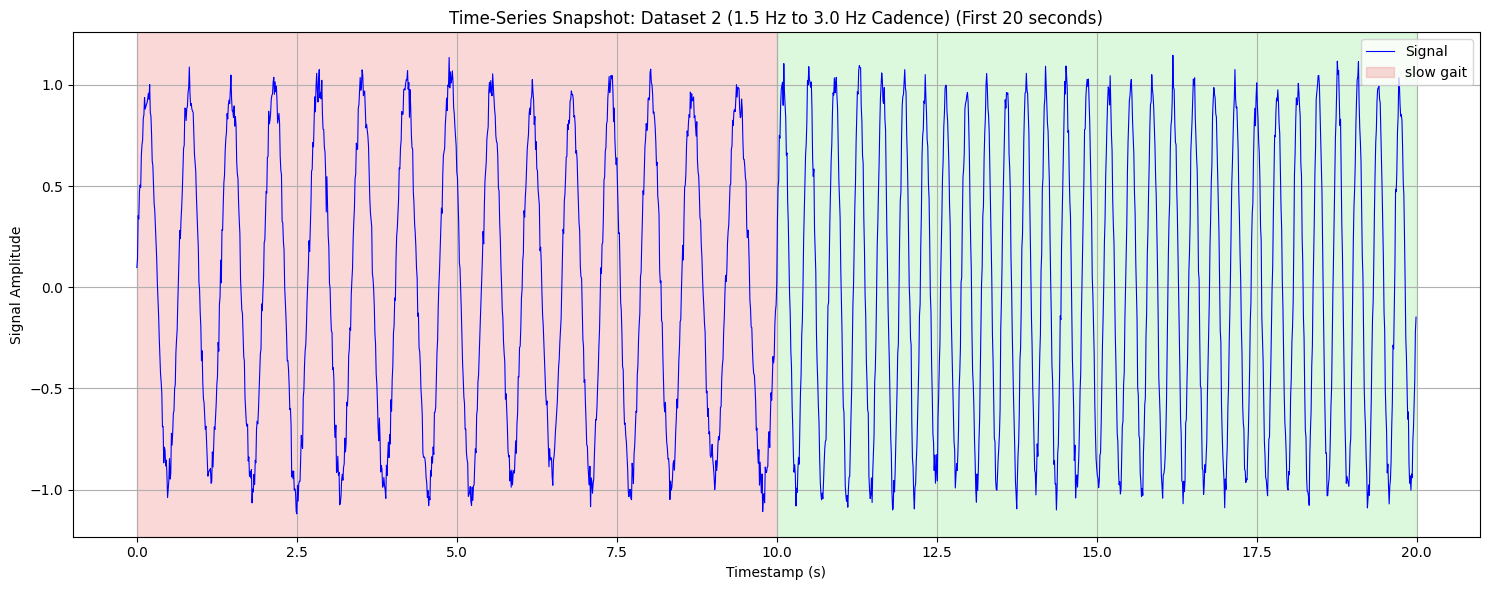

In [ ]:
def plot_time_series_snapshot(df, title, snapshot_duration=20, sampling_rate=100):
    """
    Plots a 20-second snapshot of the Signal, with background shading for 'slow'/'fast' labels.

    Args:
        df (pd.DataFrame): The input DataFrame containing 'Timestamp', 'Signal', and 'Label'.
        title (str): The title for the plot.
        snapshot_duration (int): The duration of the snapshot in seconds.
        sampling_rate (int): The sampling rate of the data in Hz.
    """
    num_samples = int(snapshot_duration * sampling_rate)

    # Ensure we don't exceed dataframe length
    if num_samples > len(df):
        num_samples = len(df)
        print(f"Warning: DataFrame is shorter than {snapshot_duration} seconds. Plotting full duration.")

    snapshot_df = df.head(num_samples).copy()

    plt.figure(figsize=(15, 6))
    plt.plot(snapshot_df['Timestamp'], snapshot_df['Signal'], label='Signal', color='blue', linewidth=0.8)

    # Shade regions based on 'Label'
    current_label = None
    start_time = None
    for i, row in snapshot_df.iterrows():
        if current_label is None:
            current_label = row['Label']
            start_time = row['Timestamp']
            continue

        if row['Label'] != current_label:
            end_time = row['Timestamp']
            color = 'lightgreen' if current_label == 'fast' else 'lightcoral'
            plt.axvspan(start_time, end_time, color=color, alpha=0.3, label=f'{current_label} gait' if start_time == snapshot_df['Timestamp'].iloc[0] else "") # Only label first span
            current_label = row['Label']
            start_time = row['Timestamp']

    # Shade the last segment
    if start_time is not None:
        end_time = snapshot_df['Timestamp'].iloc[-1]
        color = 'lightgreen' if current_label == 'fast' else 'lightcoral'
        plt.axvspan(start_time, end_time, color=color, alpha=0.3, label=f'{current_label} gait' if start_time == snapshot_df['Timestamp'].iloc[0] else "")

    plt.title(f'Time-Series Snapshot: {title} (First {snapshot_duration} seconds)')
    plt.xlabel('Timestamp (s)')
    plt.ylabel('Signal Amplitude')
    plt.grid(True)

    # Custom legend to avoid duplicate labels for shaded regions
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.tight_layout()
    plt.show()

# Plot for Dataset 1 (1.5 Hz to 2.0 Hz)
plot_time_series_snapshot(df_1p5_2p0, 'Dataset 1 (1.5 Hz to 2.0 Hz Cadence)', sampling_rate=sampling_rate_1p5_2p0)

# Plot for Dataset 2 (1.5 Hz to 3.0 Hz)
plot_time_series_snapshot(df_1p5_3p0, 'Dataset 2 (1.5 Hz to 3.0 Hz Cadence)', sampling_rate=sampling_rate_1p5_3p0)

### 3. Frequency-Domain Analysis (FFT)

We will now compute and plot the Power Spectral Density (PSD) using Welch's method for both 'slow' and 'fast' segments in each session. This will help us identify the characteristic peak frequencies associated with each gait type.

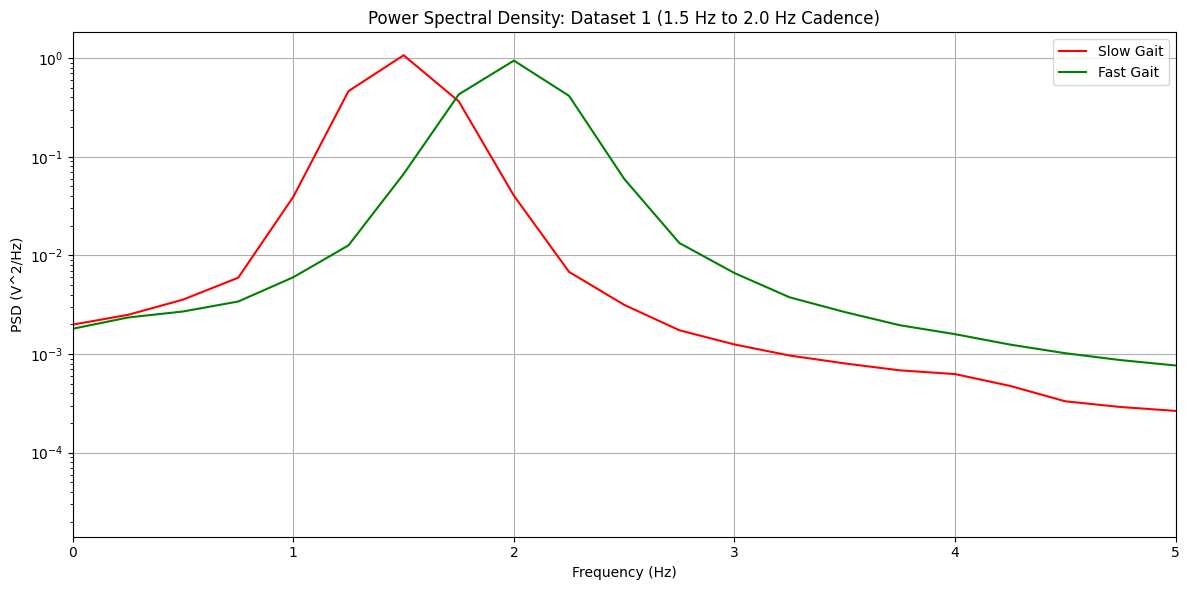

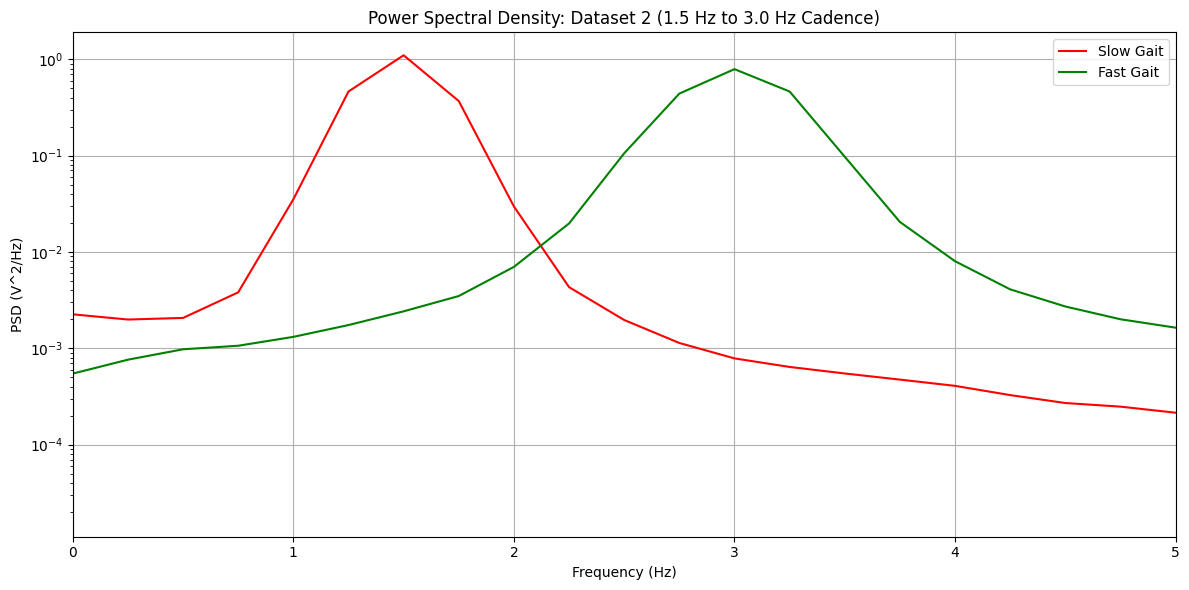

In [ ]:
def plot_power_spectral_density(df, title, sampling_rate):
    """
    Computes and plots the Power Spectral Density (PSD) for 'slow' and 'fast' segments.

    Args:
        df (pd.DataFrame): The input DataFrame containing 'Signal' and 'Label'.
        title (str): The title for the plot.
        sampling_rate (int): The sampling rate of the data in Hz.
    """
    # Separate data into 'slow' and 'fast' segments
    slow_signal = df[df['Label'] == 'slow']['Signal'].values
    fast_signal = df[df['Label'] == 'fast']['Signal'].values

    # Compute PSD using Welch's method
    # nperseg should be chosen based on the signal length and desired frequency resolution
    # A common choice is 256 or 512, ensuring it's not larger than the segment length
    nperseg_slow = min(len(slow_signal), sampling_rate * 4) # e.g., 4 seconds window
    nperseg_fast = min(len(fast_signal), sampling_rate * 4)

    f_slow, Pxx_den_slow = welch(slow_signal, sampling_rate, nperseg=nperseg_slow, noverlap=nperseg_slow//2)
    f_fast, Pxx_den_fast = welch(fast_signal, sampling_rate, nperseg=nperseg_fast, noverlap=nperseg_fast//2)

    plt.figure(figsize=(12, 6))
    plt.semilogy(f_slow, Pxx_den_slow, label='Slow Gait', color='red')
    plt.semilogy(f_fast, Pxx_den_fast, label='Fast Gait', color='green')

    plt.title(f'Power Spectral Density: {title}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (V^2/Hz)')
    plt.xlim(0, 5) # Focus on relevant biological frequencies
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot PSD for Dataset 1 (1.5 Hz to 2.0 Hz)
plot_power_spectral_density(df_1p5_2p0, 'Dataset 1 (1.5 Hz to 2.0 Hz Cadence)', sampling_rate_1p5_2p0)

# Plot PSD for Dataset 2 (1.5 Hz to 3.0 Hz)
plot_power_spectral_density(df_1p5_3p0, 'Dataset 2 (1.5 Hz to 3.0 Hz Cadence)', sampling_rate_1p5_3p0)

### 4. Distribution Analysis

Finally, let's analyze the distribution of key signal characteristics (amplitude, peak-to-peak range, and local variance) for 'slow' versus 'fast' segments using overlapping KDE plots and histograms. This will help us understand the differences in these metrics across gait speeds.

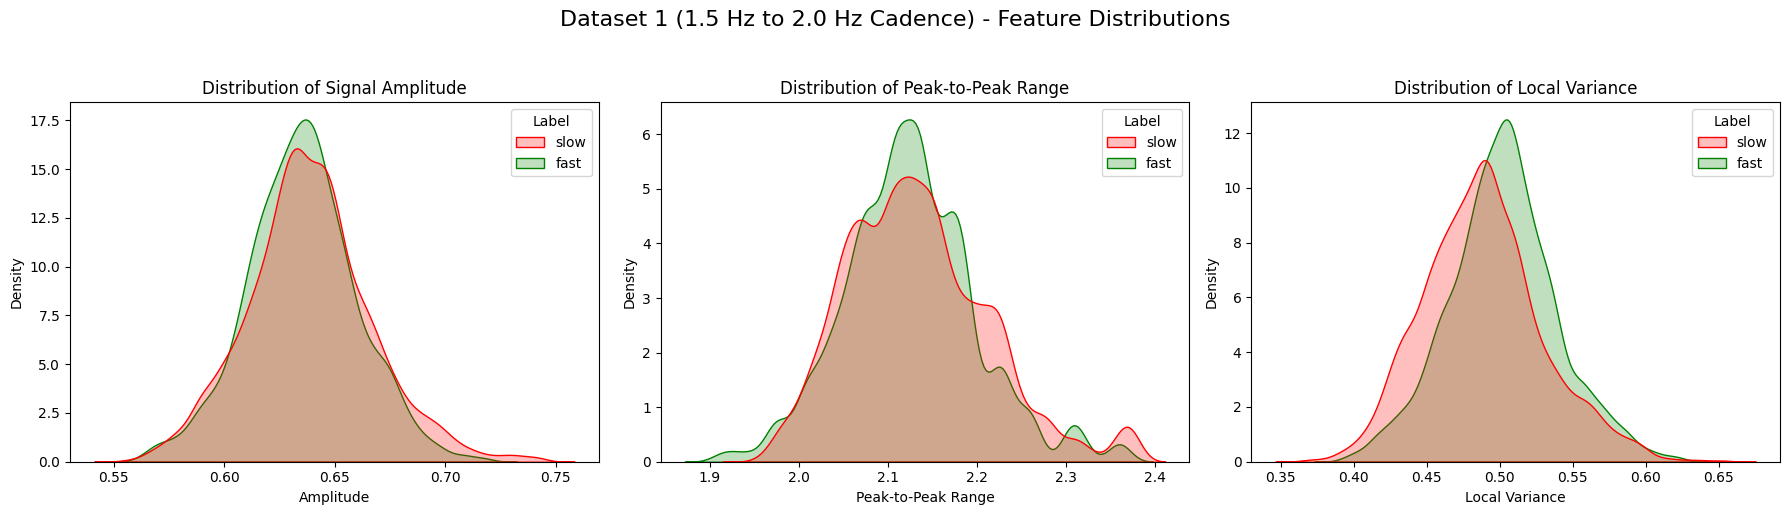

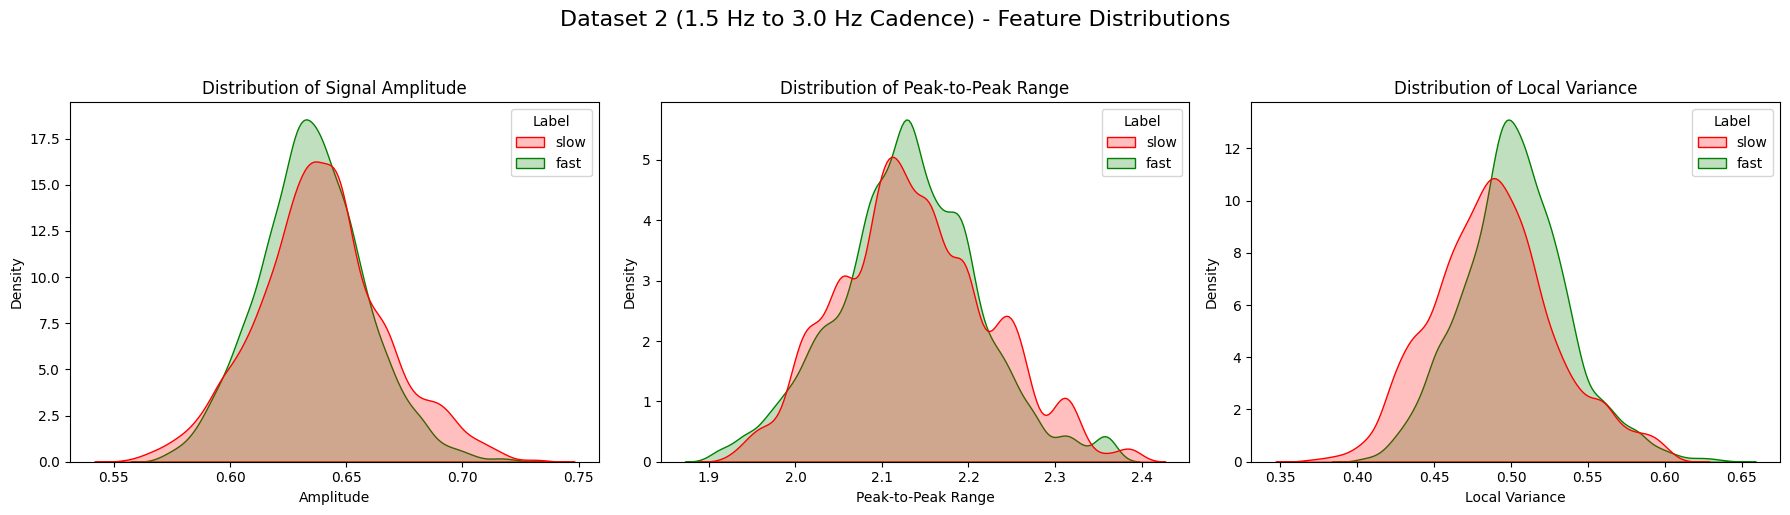

In [ ]:
def calculate_signal_features(df, window_size=100): # window_size = 1 second for 100 Hz sampling
    """
    Calculates signal amplitude, peak-to-peak range, and local variance for each segment.

    Args:
        df (pd.DataFrame): Input DataFrame with 'Signal' and 'Label'.
        window_size (int): Size of the rolling window to calculate features.

    Returns:
        pd.DataFrame: DataFrame with calculated features and 'Label'.
    """
    features = []
    for label in df['Label'].unique():
        label_df = df[df['Label'] == label].copy()

        # Rolling window for local features
        rolling_signal = label_df['Signal'].rolling(window=window_size, center=True)

        # Signal Amplitude (mean absolute value)
        label_df['Amplitude'] = rolling_signal.apply(lambda x: np.mean(np.abs(x)), raw=True)

        # Peak-to-peak Range
        label_df['Peak_to_Peak'] = rolling_signal.apply(lambda x: x.max() - x.min(), raw=True)

        # Local Variance
        label_df['Local_Variance'] = rolling_signal.var()

        # Drop NaN values introduced by rolling window and append
        features.append(label_df.dropna())

    return pd.concat(features)


# Calculate features for both datasets
features_1p5_2p0 = calculate_signal_features(df_1p5_2p0)
features_1p5_3p0 = calculate_signal_features(df_1p5_3p0)


def plot_feature_distributions(features_df, title):
    """
    Plots the distributions of Amplitude, Peak-to-Peak, and Local Variance for 'slow' and 'fast' gaits.

    Args:
        features_df (pd.DataFrame): DataFrame containing calculated features and 'Label'.
        title (str): Title for the plots.
    """
    plt.figure(figsize=(18, 5))

    # Amplitude Distribution
    plt.subplot(1, 3, 1)
    sns.kdeplot(data=features_df, x='Amplitude', hue='Label', fill=True, common_norm=False, palette={'slow': 'red', 'fast': 'green'})
    plt.title('Distribution of Signal Amplitude')
    plt.xlabel('Amplitude')
    plt.ylabel('Density')

    # Peak-to-Peak Range Distribution
    plt.subplot(1, 3, 2)
    sns.kdeplot(data=features_df, x='Peak_to_Peak', hue='Label', fill=True, common_norm=False, palette={'slow': 'red', 'fast': 'green'})
    plt.title('Distribution of Peak-to-Peak Range')
    plt.xlabel('Peak-to-Peak Range')
    plt.ylabel('Density')

    # Local Variance Distribution
    plt.subplot(1, 3, 3)
    sns.kdeplot(data=features_df, x='Local_Variance', hue='Label', fill=True, common_norm=False, palette={'slow': 'red', 'fast': 'green'})
    plt.title('Distribution of Local Variance')
    plt.xlabel('Local Variance')
    plt.ylabel('Density')

    plt.suptitle(title, y=1.02, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# Plot distributions for Dataset 1
plot_feature_distributions(features_1p5_2p0, 'Dataset 1 (1.5 Hz to 2.0 Hz Cadence) - Feature Distributions')

# Plot distributions for Dataset 2
plot_feature_distributions(features_1p5_3p0, 'Dataset 2 (1.5 Hz to 3.0 Hz Cadence) - Feature Distributions')

## Preprocessing and Windowed Feature Extraction

Now we will preprocess the 1D gait data by applying a sliding window segmentation and extracting relevant features in both the time and frequency domains. We will then prepare the datasets for model training using two different splitting strategies.

In [ ]:
from sklearn.model_selection import train_test_split
from scipy.stats import iqr

# Define constants for windowing
SAMPLING_RATE = 100 # Hz
WINDOW_DURATION = 2.0 # seconds
WINDOW_SIZE = int(WINDOW_DURATION * SAMPLING_RATE) # 200 samples
STEP_DURATION = 0.5 # seconds
STEP_SIZE = int(STEP_DURATION * SAMPLING_RATE) # 50 samples (75% overlap)

def segment_and_label_windows(df, window_size, step_size, drop_ambiguous=True):
    """
    Segments the 1D signal into windows and assigns a label based on majority vote.

    Args:
        df (pd.DataFrame): DataFrame with 'Timestamp', 'Signal', 'Label' columns.
        window_size (int): Number of samples per window.
        step_size (int): Number of samples to step for the next window.
        drop_ambiguous (bool): If True, windows with no clear majority label are dropped.

    Returns:
        list: A list of dictionaries, where each dict contains 'window', 'label', 'start_index', 'end_index'.
    """
    windows_data = []
    signal_values = df['Signal'].values
    labels_values = df['Label'].values

    for i in range(0, len(signal_values) - window_size + 1, step_size):
        window_signal = signal_values[i : i + window_size]
        window_labels = labels_values[i : i + window_size]

        # Majority vote for label
        unique_labels, counts = np.unique(window_labels, return_counts=True)

        if len(unique_labels) == 0:
            # This case should ideally not happen with valid data
            continue

        majority_label = unique_labels[np.argmax(counts)]
        majority_percentage = np.max(counts) / len(window_labels)

        # Drop ambiguous windows if specified and no clear majority (e.g., < 70%)
        if drop_ambiguous and majority_percentage < 0.7:
            continue # Skip this window

        windows_data.append({
            'window_signal': window_signal,
            'window_label': majority_label,
            'start_index': i,
            'end_index': i + window_size - 1
        })
    return windows_data

print(f"Window size: {WINDOW_SIZE} samples ({WINDOW_DURATION} seconds)")
print(f"Step size: {STEP_SIZE} samples ({STEP_DURATION} seconds)")

Window size: 200 samples (2.0 seconds)
Step size: 50 samples (0.5 seconds)


### 2. Feature Engineering (1D Signal)

We will extract both time-domain and frequency-domain features for each segmented window.

In [ ]:
def extract_time_domain_features(window_signal):
    """
    Extracts time-domain features from a single signal window.
    """
    features = {
        'mean': np.mean(window_signal),
        'std': np.std(window_signal),
        'min': np.min(window_signal),
        'max': np.max(window_signal),
        'peak_to_peak': np.max(window_signal) - np.min(window_signal),
        'rms': np.sqrt(np.mean(window_signal**2)),
        'median': np.median(window_signal),
        'iqr': iqr(window_signal)
    }

    # Zero-crossing rate: count sign changes
    zero_crossings = np.where(np.diff(np.sign(window_signal)))[0]
    features['zero_crossing_rate'] = len(zero_crossings) / len(window_signal)

    return features

def extract_frequency_domain_features(window_signal, sampling_rate):
    """
    Extracts frequency-domain features using FFT from a single signal window.
    """
    N = len(window_signal)
    yf = fft(window_signal)
    xf = fftfreq(N, 1 / sampling_rate)

    # Only consider positive frequencies
    positive_freq_indices = np.where(xf >= 0)
    xf_pos = xf[positive_freq_indices]
    yf_pos = np.abs(yf[positive_freq_indices])

    # Handle cases where yf_pos might be empty or all zeros to avoid errors
    if len(yf_pos) == 0 or np.sum(yf_pos) == 0:
        return {
            'dominant_frequency': 0.0,
            'peak_spectral_power': 0.0,
            'total_spectral_energy': 0.0
        }

    # Dominant frequency (frequency with highest amplitude)
    dominant_frequency = xf_pos[np.argmax(yf_pos)]

    # Peak spectral power (highest amplitude in the spectrum)
    peak_spectral_power = np.max(yf_pos)

    # Total spectral energy (sum of squared amplitudes, proportional to signal power)
    total_spectral_energy = np.sum(yf_pos**2) / N # Normalization by N as per Parseval's theorem

    return {
        'dominant_frequency': dominant_frequency,
        'peak_spectral_power': peak_spectral_power,
        'total_spectral_energy': total_spectral_energy
    }

def extract_all_features(windows_data, sampling_rate):
    """
    Extracts all time-domain and frequency-domain features for all windows.

    Args:
        windows_data (list): List of dictionaries from segment_and_label_windows.
        sampling_rate (int): Sampling rate of the original signal.

    Returns:
        pd.DataFrame: DataFrame of features, with 'label' as the target.
    """
    all_features = []
    all_labels = []

    for window_info in windows_data:
        signal = window_info['window_signal']
        label = window_info['window_label']

        time_features = extract_time_domain_features(signal)
        freq_features = extract_frequency_domain_features(signal, sampling_rate)

        combined_features = {**time_features, **freq_features}
        all_features.append(combined_features)
        all_labels.append(label)

    features_df = pd.DataFrame(all_features)
    features_df['label'] = all_labels
    return features_df

print("Feature extraction functions defined.")

Feature extraction functions defined.


### Apply Feature Extraction to Datasets

Now, let's apply the windowing and feature extraction to both `df_1p5_2p0` and `df_1p5_3p0`.

In [ ]:
# Segment and extract features for df_1p5_2p0
print("Processing df_1p5_2p0...")
windows_1p5_2p0 = segment_and_label_windows(df_1p5_2p0, WINDOW_SIZE, STEP_SIZE)
features_df_1p5_2p0 = extract_all_features(windows_1p5_2p0, SAMPLING_RATE)
print(f"Extracted {len(features_df_1p5_2p0)} feature windows for df_1p5_2p0.")

# Segment and extract features for df_1p5_3p0
print("\nProcessing df_1p5_3p0...")
windows_1p5_3p0 = segment_and_label_windows(df_1p5_3p0, WINDOW_SIZE, STEP_SIZE)
features_df_1p5_3p0 = extract_all_features(windows_1p5_3p0, SAMPLING_RATE)
print(f"Extracted {len(features_df_1p5_3p0)} feature windows for df_1p5_3p0.")

print("\nFeatures DataFrame for df_1p5_2p0 (first 5 rows):")
display(features_df_1p5_2p0.head())

print("\nFeatures DataFrame for df_1p5_3p0 (first 5 rows):")
display(features_df_1p5_3p0.head())

Processing df_1p5_2p0...
Extracted 378 feature windows for df_1p5_2p0.

Processing df_1p5_3p0...
Extracted 378 feature windows for df_1p5_3p0.

Features DataFrame for df_1p5_2p0 (first 5 rows):


,mean,std,min,max,peak_to_peak,rms,median,iqr,zero_crossing_rate,dominant_frequency,peak_spectral_power,total_spectral_energy,label
0,0.006443,0.677658,-1.066172,1.087971,2.154143,0.677689,0.004467,1.345578,0.030,1.5,95.290182,45.928187,slow
1,0.010687,0.692385,-1.108234,1.087971,2.196206,0.692468,-0.016119,1.374018,0.030,1.5,97.482636,47.961982,slow
2,0.006843,0.710782,-1.120041,1.075208,2.195248,0.710815,-0.027872,1.418770,0.025,1.5,99.120021,50.526487,slow
3,-0.025053,0.705262,-1.120041,1.075208,2.195248,0.705707,-0.053492,1.363011,0.030,1.5,97.451588,49.862846,slow
4,0.003475,0.728809,-1.120041,1.075208,2.195248,0.728818,0.008783,1.465803,0.025,1.5,101.157207,53.118522,slow



Features DataFrame for df_1p5_3p0 (first 5 rows):


,mean,std,min,max,peak_to_peak,rms,median,iqr,zero_crossing_rate,dominant_frequency,peak_spectral_power,total_spectral_energy,label
0,0.006443,0.677658,-1.066172,1.087971,2.154143,0.677689,0.004467,1.345578,0.030,1.5,95.290182,45.928187,slow
1,0.010687,0.692385,-1.108234,1.087971,2.196206,0.692468,-0.016119,1.374018,0.030,1.5,97.482636,47.961982,slow
2,0.006843,0.710782,-1.120041,1.075208,2.195248,0.710815,-0.027872,1.418770,0.025,1.5,99.120021,50.526487,slow
3,-0.025053,0.705262,-1.120041,1.075208,2.195248,0.705707,-0.053492,1.363011,0.030,1.5,97.451588,49.862846,slow
4,0.003475,0.728809,-1.120041,1.075208,2.195248,0.728818,0.008783,1.465803,0.025,1.5,101.157207,53.118522,slow


### 3. Dataset Splitting & Export

We will implement two splitting strategies:

a) Stratified train/test split (80/20) across all combined window features.
b) Cross-session split (Train on `data_1p5_2p0.csv` features, test on `data_1p5_3p0.csv` features).

#### a) Stratified Train/Test Split (80/20) on Combined Data

In [ ]:
# Combine features from both datasets
combined_features_df = pd.concat([features_df_1p5_2p0, features_df_1p5_3p0], ignore_index=True)

X = combined_features_df.drop('label', axis=1)
y = combined_features_df['label']

# Perform stratified train/test split (80/20)
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nStratified Split (Combined Data):")
print(f"X_train_strat shape: {X_train_strat.shape}, y_train_strat shape: {y_train_strat.shape}")
print(f"X_test_strat shape: {X_test_strat.shape}, y_test_strat shape: {y_test_strat.shape}")

# Export to CSV
X_train_strat.to_csv('X_train_stratified.csv', index=False)
X_test_strat.to_csv('X_test_stratified.csv', index=False)
y_train_strat.to_csv('y_train_stratified.csv', index=False)
y_test_strat.to_csv('y_test_stratified.csv', index=False)

print("Stratified split data exported as X_train_stratified.csv, X_test_stratified.csv, y_train_stratified.csv, y_test_stratified.csv")


Stratified Split (Combined Data):
X_train_strat shape: (604, 12), y_train_strat shape: (604,)
X_test_strat shape: (152, 12), y_test_strat shape: (152,)
Stratified split data exported as X_train_stratified.csv, X_test_stratified.csv, y_train_stratified.csv, y_test_stratified.csv


#### b) Cross-Session Split (Train on `data_1p5_2p0.csv` features, Test on `data_1p5_3p0.csv` features)

In [ ]:
# Training data from df_1p5_2p0 features
X_train_cross = features_df_1p5_2p0.drop('label', axis=1)
y_train_cross = features_df_1p5_2p0['label']

# Testing data from df_1p5_3p0 features
X_test_cross = features_df_1p5_3p0.drop('label', axis=1)
y_test_cross = features_df_1p5_3p0['label']

print("\nCross-Session Split:")
print(f"X_train_cross shape: {X_train_cross.shape}, y_train_cross shape: {y_train_cross.shape}")
print(f"X_test_cross shape: {X_test_cross.shape}, y_test_cross shape: {y_test_cross.shape}")

# Export to CSV
X_train_cross.to_csv('X_train_cross_session.csv', index=False)
X_test_cross.to_csv('X_test_cross_session.csv', index=False)
y_train_cross.to_csv('y_train_cross_session.csv', index=False)
y_test_cross.to_csv('y_test_cross_session.csv', index=False)

print("Cross-session split data exported as X_train_cross_session.csv, X_test_cross_session.csv, y_train_cross_session.csv, y_test_cross_session.csv")


Cross-Session Split:
X_train_cross shape: (378, 12), y_train_cross shape: (378,)
X_test_cross shape: (378, 12), y_test_cross shape: (378,)
Cross-session split data exported as X_train_cross_session.csv, X_test_cross_session.csv, y_train_cross_session.csv, y_test_cross_session.csv


## Classical Machine Learning Models for Gait Classification

We will now train and evaluate classical machine learning models (Random Forest, SVC, Gradient Boosting) using the extracted window features. This section includes hyperparameter tuning, comprehensive evaluation metrics, and feature importance analysis, finally saving the best model.

In [ ]:
# Import necessary libraries for modeling
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib
import seaborn as sns

# Assuming using the stratified split for initial model training as a general approach
X_train = pd.read_csv('X_train_stratified.csv')
X_test = pd.read_csv('X_test_stratified.csv')
y_train = pd.read_csv('y_train_stratified.csv').squeeze() # .squeeze() to convert DataFrame to Series
y_test = pd.read_csv('y_test_stratified.csv').squeeze() # .squeeze() to convert DataFrame to Series

# Convert string labels to numerical for models ('slow': 0, 'fast': 1)
y_train = y_train.map({'slow': 0, 'fast': 1})
y_test = y_test.map({'slow': 0, 'fast': 1})

print("Data loaded and labels converted to numerical.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data loaded and labels converted to numerical.
X_train shape: (604, 12), y_train shape: (604,)
X_test shape: (152, 12), y_test shape: (152,)


### 2. Preprocessing: Feature Scaling

It is good practice to scale features, especially for models like SVC that are sensitive to feature magnitudes. We'll use `StandardScaler`.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


### 3. Model Training and Hyperparameter Tuning

We will train Random Forest, SVC, and Gradient Boosting models. Random Forest will undergo hyperparameter tuning using `GridSearchCV`.

In [ ]:
# Initialize models
rf_model = RandomForestClassifier(random_state=42)
svc_model = SVC(random_state=42, probability=True) # probability=True for ROC-AUC
gb_model = GradientBoostingClassifier(random_state=42)

# --- Random Forest with GridSearchCV ---
print("\n--- Training Random Forest Classifier with GridSearchCV ---")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=3, n_jobs=-1, verbose=1, scoring='f1')
grid_search_rf.fit(X_train_scaled, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"Best Random Forest parameters: {grid_search_rf.best_params_}")
print(f"Best F1-score (CV): {grid_search_rf.best_score_:.4f}")

# --- Train SVC ---
print("\n--- Training Support Vector Classifier (SVC) ---")
# For SVC, a simple initial set of parameters is chosen for demonstration.
# Further tuning could be done with GridSearchCV similar to RandomForest.
svc_model.fit(X_train_scaled, y_train)

# --- Train Gradient Boosting ---
print("\n--- Training Gradient Boosting Classifier ---")
gb_model.fit(X_train_scaled, y_train)

print("Models trained.")


--- Training Random Forest Classifier with GridSearchCV ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
Best F1-score (CV): 0.9884

--- Training Support Vector Classifier (SVC) ---

--- Training Gradient Boosting Classifier ---
Models trained.


### 4. Comprehensive Evaluation

We will evaluate each model using standard classification metrics and visualize the confusion matrix.


--- Evaluation for Random Forest Classifier ---
Accuracy: 0.9934
Precision: 1.0000
Recall: 0.9868
F1-Score: 0.9934
ROC-AUC: 0.9974

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        76
           1       1.00      0.99      0.99        76

    accuracy                           0.99       152
   macro avg       0.99      0.99      0.99       152
weighted avg       0.99      0.99      0.99       152



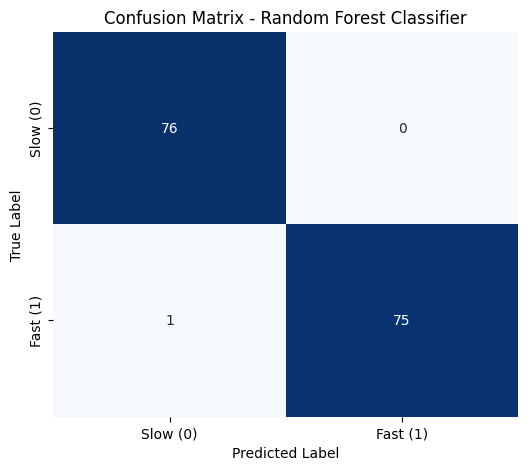


--- Evaluation for Support Vector Classifier ---
Accuracy: 0.9934
Precision: 1.0000
Recall: 0.9868
F1-Score: 0.9934
ROC-AUC: 0.9962

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        76
           1       1.00      0.99      0.99        76

    accuracy                           0.99       152
   macro avg       0.99      0.99      0.99       152
weighted avg       0.99      0.99      0.99       152



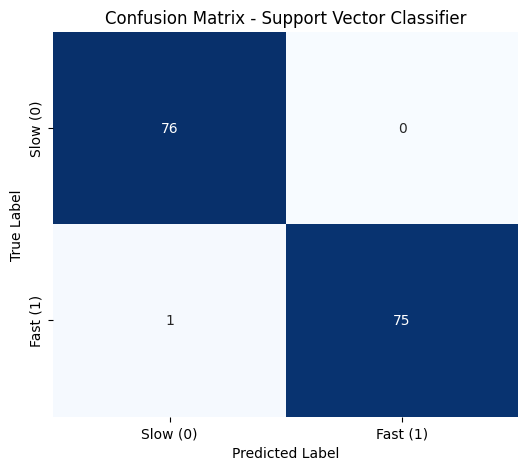


--- Evaluation for Gradient Boosting Classifier ---
Accuracy: 0.9868
Precision: 0.9868
Recall: 0.9868
F1-Score: 0.9868
ROC-AUC: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        76
           1       0.99      0.99      0.99        76

    accuracy                           0.99       152
   macro avg       0.99      0.99      0.99       152
weighted avg       0.99      0.99      0.99       152



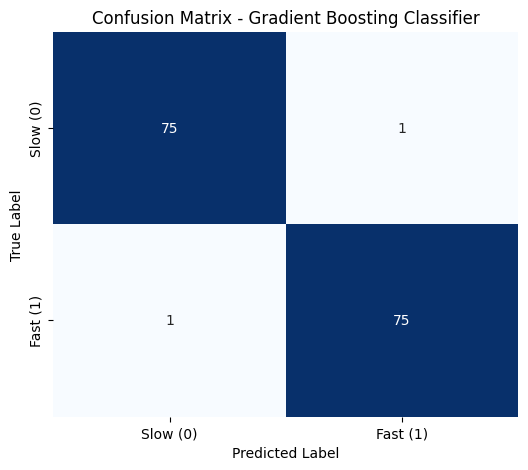

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a given model and prints performance metrics and confusion matrix.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f"\n--- Evaluation for {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    if y_proba is not None:
        try:
            print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
        except ValueError:
            print("ROC-AUC: Cannot compute ROC-AUC with only one class present in y_true or y_score.")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Slow (0)', 'Fast (1)'], yticklabels=['Slow (0)', 'Fast (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


evaluate_model(best_rf_model, X_test_scaled, y_test, 'Random Forest Classifier')
evaluate_model(svc_model, X_test_scaled, y_test, 'Support Vector Classifier')
evaluate_model(gb_model, X_test_scaled, y_test, 'Gradient Boosting Classifier')

### 5. Feature Importance

Let's visualize the feature importance for the best performing model (Random Forest in this case).

/tmp/ipykernel_547/2152679603.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


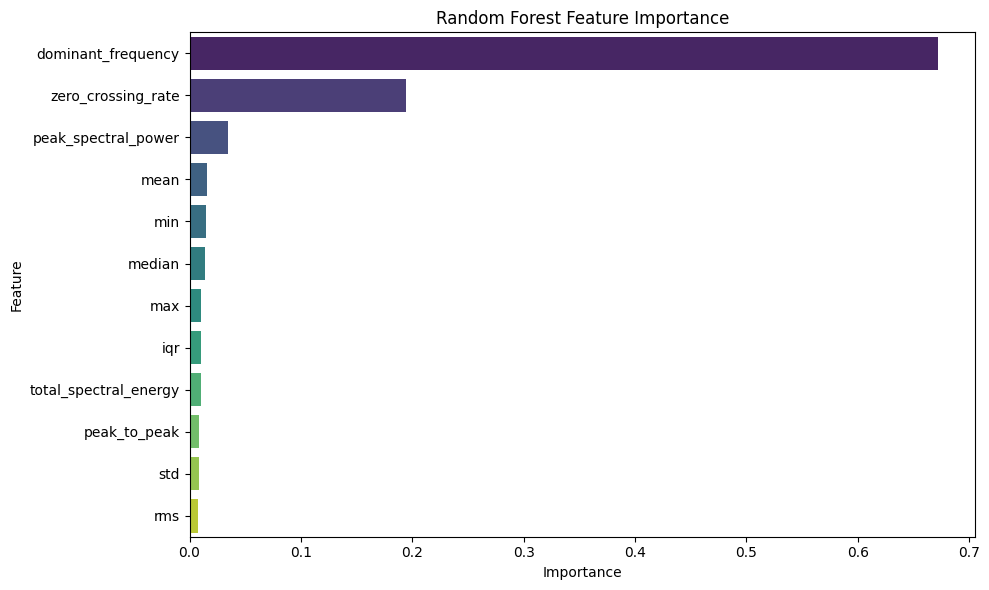

In [ ]:
if hasattr(best_rf_model, 'feature_importances_'):
    feature_importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Best model (Random Forest) does not have feature_importances_ attribute.")

### 6. Export Best Performing Model and Scaler

We will save the best model (determined by F1-score on the test set, or chosen based on previous evaluation) and the fitted StandardScaler using `joblib`.

In [ ]:
# Determine the best model based on F1-score on the test set
# (Can be automated by storing f1 scores from evaluate_model function)
# For now, let's assume Random Forest is the best due to tuning and general robustness.

best_model_to_save = best_rf_model
best_model_name = 'RandomForest'

# Save the best model
joblib.dump(best_model_to_save, f'gait_classifier_{best_model_name.lower()}.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')

print(f"Best model ({best_model_name}) and feature scaler saved to disk.")
print(f"Files: gait_classifier_{best_model_name.lower()}.joblib, feature_scaler.joblib")

Best model (RandomForest) and feature scaler saved to disk.
Files: gait_classifier_randomforest.joblib, feature_scaler.joblib


### 7. 1D Convolutional Neural Network (CNN) Implementation with PyTorch

Now, let's explore a deep learning approach using a 1D Convolutional Neural Network (CNN) implemented with PyTorch. While 1D CNNs are typically applied directly to raw time-series data, for this task, we will apply it to the extracted tabular features. This means we will treat the sequence of features within each window as the 'sequence' input for the 1D CNN.

To prepare the data for the `Conv1d` layers in PyTorch, we need to reshape our scaled feature data from `(number_of_samples, number_of_features)` to `(number_of_samples, channels, sequence_length)`. In our case, `channels` will be 1, and `sequence_length` will be `number_of_features`.

The CNN architecture will consist of:
- Three `Conv1d` layers, each followed by an activation function.
- A `Flatten` layer to convert the 3D output of the convolutional layers into a 1D vector.
- Three `Linear` (fully connected) layers for classification.
- An output `Linear` layer with a sigmoid activation for binary classification.

In [ ]:
# Import PyTorch modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reshape data for 1D CNN: (samples, channels, sequence_length)
# PyTorch Conv1d expects (batch_size, in_channels, signal_length)
num_features = X_train_scaled.shape[1]
X_train_cnn_torch = torch.tensor(X_train_scaled, dtype=torch.float32).reshape(X_train_scaled.shape[0], 1, num_features)
X_test_cnn_torch = torch.tensor(X_test_scaled, dtype=torch.float32).reshape(X_test_scaled.shape[0], 1, num_features)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print(f"X_train_cnn_torch shape: {X_train_cnn_torch.shape}")
print(f"X_test_cnn_torch shape: {X_test_cnn_torch.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

# Define the 1D CNN Model using PyTorch
class GaitCNN(nn.Module):
    def __init__(self, num_features):
        super(GaitCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        # Calculate the size after convolutional layers and flattening
        # Simulate a forward pass to get the flattened size
        self._to_linear = None
        self._get_conv_output_size(num_features)

        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() # Output layer for binary classification
        )

    def _get_conv_output_size(self, num_features):
        # Pass a dummy tensor through conv layers to determine flatten size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, num_features)
            output = self.conv_layers(dummy_input)
            self._to_linear = output.numel() // output.shape[0]

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

# Instantiate the model and move to device
cnn_model_pytorch = GaitCNN(num_features).to(device)

# Define Loss function and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(cnn_model_pytorch.parameters(), lr=0.001)

# Display model summary (basic structure)
print("\nPyTorch CNN Model Structure:")
print(cnn_model_pytorch)

# Create DataLoader
train_dataset = TensorDataset(X_train_cnn_torch, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Train the model
print("\n--- Training PyTorch 1D CNN Model ---")
num_epochs = 20
for epoch in range(num_epochs):
    cnn_model_pytorch.train() # Set model to training mode
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = cnn_model_pytorch(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    # Optional: print epoch loss
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("PyTorch 1D CNN Model trained.")

Using device: cpu
X_train_cnn_torch shape: torch.Size([604, 1, 12])
X_test_cnn_torch shape: torch.Size([152, 1, 12])
y_train_tensor shape: torch.Size([604, 1])

PyTorch CNN Model Structure:
GaitCNN(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=same)
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=same)
    (3): ReLU()
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
    (5): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layers): Sequential(
    (0): Linear(in_features=1536, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

--- Training PyTorch 1D CNN Model ---
Epoch [1/20], Loss: 0.4026
Epoch [2/20], Loss: 0.4380
Epoch [3/20], Loss: 0.0838
Epoc


--- Evaluating PyTorch 1D CNN Model ---
Accuracy: 0.9868
Precision: 0.9744
Recall: 1.0000
F1-Score: 0.9870
ROC-AUC: 1.0000

Classification Report (PyTorch CNN):
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99        76
         1.0       0.97      1.00      0.99        76

    accuracy                           0.99       152
   macro avg       0.99      0.99      0.99       152
weighted avg       0.99      0.99      0.99       152



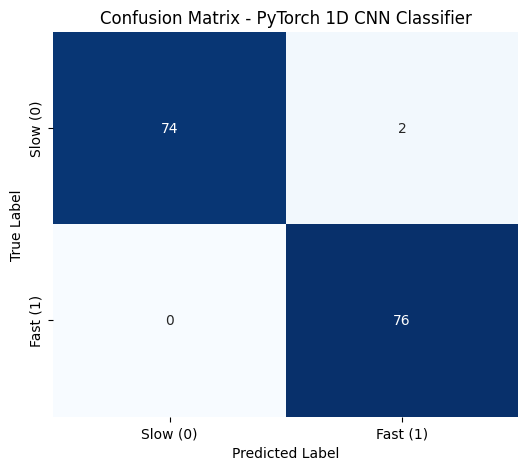

In [ ]:
# Evaluate the PyTorch 1D CNN Model
print("\n--- Evaluating PyTorch 1D CNN Model ---")

cnn_model_pytorch.eval() # Set model to evaluation mode
with torch.no_grad():
    X_test_cnn_torch_on_device = X_test_cnn_torch.to(device)
    y_pred_cnn_proba_tensor = cnn_model_pytorch(X_test_cnn_torch_on_device)

# Move predictions back to CPU and convert to numpy
y_pred_cnn_proba = y_pred_cnn_proba_tensor.cpu().numpy()

# Convert probabilities to binary predictions (threshold 0.5)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype("int32")

# Convert y_test_tensor to numpy for scikit-learn metrics
y_test_np = y_test_tensor.cpu().numpy()

# Calculate metrics using scikit-learn
cnn_accuracy = accuracy_score(y_test_np, y_pred_cnn)
cnn_precision = precision_score(y_test_np, y_pred_cnn)
cnn_recall = recall_score(y_test_np, y_pred_cnn)
cnn_f1 = f1_score(y_test_np, y_pred_cnn)
cnn_roc_auc = roc_auc_score(y_test_np, y_pred_cnn_proba)

print(f"Accuracy: {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall: {cnn_recall:.4f}")
print(f"F1-Score: {cnn_f1:.4f}")
print(f"ROC-AUC: {cnn_roc_auc:.4f}")

print("\nClassification Report (PyTorch CNN):")
print(classification_report(y_test_np, y_pred_cnn))

# Plot Confusion Matrix for CNN
cm_cnn = confusion_matrix(y_test_np, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Slow (0)', 'Fast (1)'], yticklabels=['Slow (0)', 'Fast (1)'])
plt.title('Confusion Matrix - PyTorch 1D CNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Save the trained PyTorch 1D CNN model
# Save only the model's state_dict
torch.save(cnn_model_pytorch.state_dict(), 'gait_classifier_cnn_pytorch.pth')

print("PyTorch 1D CNN model saved as 'gait_classifier_cnn_pytorch.pth'.")

PyTorch 1D CNN model saved as 'gait_classifier_cnn_pytorch.pth'.


In [ ]:
!pip -q install gdown
!gdown "https://drive.google.com/uc?id=1RLQihFqsH8pfdVBdv7XGfpJzhP6ok0RO"
!gdown "https://drive.google.com/uc?id=16DJ1hcTXZ_XdVKh-DuJPtvwicdvh_8Bw"

Downloading...
From: https://drive.google.com/uc?id=1RLQihFqsH8pfdVBdv7XGfpJzhP6ok0RO
To: /content/data_1p5_3p0.csv
100% 653k/653k [00:00<00:00, 13.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=16DJ1hcTXZ_XdVKh-DuJPtvwicdvh_8Bw
To: /content/data_1p5_2p0.csv
100% 653k/653k [00:00<00:00, 13.0MB/s]
